In [56]:
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import shap
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Load Data

In [57]:
X_train = pd.read_csv("./Data/Dataset/x_train.csv")
X_test  = pd.read_csv("./Data/Dataset/x_test.csv")
y_train = pd.read_csv("./Data/Dataset/y_train.csv").squeeze()  # squeeze to Series
y_test  = pd.read_csv("./Data/Dataset/y_test.csv").squeeze()

Evaluation Helper Function

In [58]:
def evaluate(name, model, X, y, feature_number):
    preds = model.predict(X)
    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds)
    rec  = recall_score(y, preds)
    f1   = f1_score(y, preds)
    cm   = confusion_matrix(y, preds)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}  (of predicted positives, how many were right)")
    print(f"  Recall   : {rec:.4f}  (of actual positives, how many did we catch)")
    print(f"  F1 Score : {f1:.4f}  (harmonic mean of precision & recall)")
    print(f"\n  Confusion Matrix:")
    print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
    # GridSearchCV objects expose best_params_; Pipeline objects don't
    if hasattr(model, 'best_params_'):
        print(f"\n  Best params: {model.best_params_}")

    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    plt.tight_layout()
    plt.savefig(f"./Data/Results/ConfusionMatrices/cm_{name.replace(' ', '_')}.png", dpi=150)
    plt.close()

    return {"Model Name": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "TN": cm[0,0], "FP": cm[0,1],
            "FN": cm[1,0], "TP": cm[1,1], "Feature_number": feature_number}


In [59]:
results = []

Logistic Regression

In [60]:
print("Training Logistic Regression...")

lr_params = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    cv=5,           # 5-fold cross-validation
    scoring='accuracy',   # optimise for accuracy
    n_jobs=-1
)
lr.fit(X_train, y_train)
results.append(evaluate("Logistic Regression", lr, X_test, y_test, X_train.shape[1]))

Training Logistic Regression...

  Logistic Regression
  Accuracy : 0.8364
  Precision: 0.8261  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8085  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=27  FP=4
  FN=5  TP=19

  Best params: {'C': 0.1, 'solver': 'lbfgs'}


LR Hyperparameter Impact

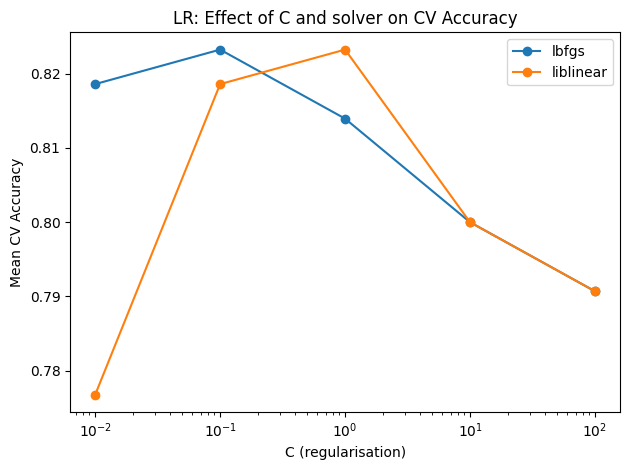

In [61]:
cv_df = pd.DataFrame(lr.cv_results_)

for solver in ['lbfgs', 'liblinear']:
    subset = cv_df[cv_df['param_solver'] == solver]
    plt.plot(subset['param_C'], subset['mean_test_score'],
             marker='o', label=solver)

plt.xscale('log')
plt.xlabel('C (regularisation)')
plt.ylabel('Mean CV Accuracy')
plt.title('LR: Effect of C and solver on CV Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('./Data/Results/HyperparamImpact/hyperparam_lr.png', dpi=150)
plt.show()

SVM

In [62]:
print("Training SVM...")

svm_params = {
    'C':      [0.1, 1, 10, 100],   # regularisation strength — controls the
                                    # margin width vs. misclassification trade-off
    'kernel': ['linear', 'rbf']     # linear = straight boundary, rbf = curved
                                    # boundary for non-linearly separable data
}

svm = GridSearchCV(
    SVC(probability=True,    # needed so the model can output confidence scores,
                             # not just hard labels — required by some downstream steps
        random_state=42),    # makes results reproducible across runs
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm.fit(X_train, y_train)
results.append(evaluate("SVM", svm, X_test, y_test, X_train.shape[1]))

Training SVM...

  SVM
  Accuracy : 0.8182
  Precision: 0.7917  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.7917  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=26  FP=5
  FN=5  TP=19

  Best params: {'C': 1, 'kernel': 'linear'}


SVM Hyperparameter Impact

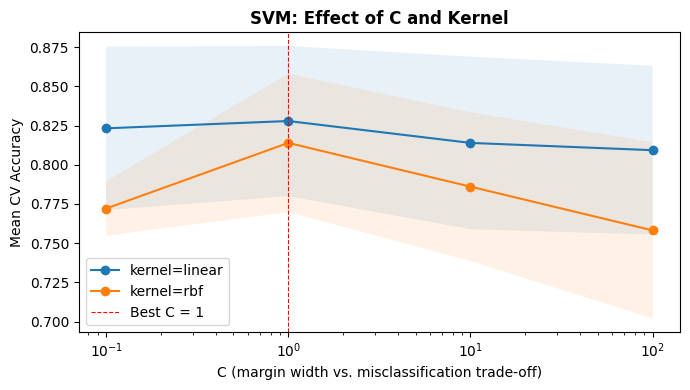

In [63]:
cv_df = pd.DataFrame(svm.cv_results_)

fig, ax = plt.subplots(figsize=(7, 4))
for kernel in ['linear', 'rbf']:
    subset = cv_df[cv_df['param_kernel'] == kernel].sort_values('param_C')
    ax.plot(subset['param_C'], subset['mean_test_score'],
            marker='o', label=f'kernel={kernel}')
    ax.fill_between(subset['param_C'],
                    subset['mean_test_score'] - subset['std_test_score'],
                    subset['mean_test_score'] + subset['std_test_score'],
                    alpha=0.1)

ax.axvline(svm.best_params_['C'], color='red', linestyle='--', linewidth=0.8,
           label=f"Best C = {svm.best_params_['C']}")
ax.set_xscale('log')
ax.set_xlabel('C (margin width vs. misclassification trade-off)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('SVM: Effect of C and Kernel', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./Data/Results/HyperparamImpact/hyperparam_svm.png', dpi=150)
plt.show()

Decision Tree

In [64]:
print("Training Decision Tree...")

dt_params = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10, 20]
}

dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
dt.fit(X_train, y_train)
results.append(evaluate("Decision Tree", dt, X_test, y_test, X_train.shape[1]))

Training Decision Tree...

  Decision Tree
  Accuracy : 0.8545
  Precision: 0.8636  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8261  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=28  FP=3
  FN=5  TP=19

  Best params: {'max_depth': 3, 'min_samples_split': 2}


DT Hyperparameter Impact

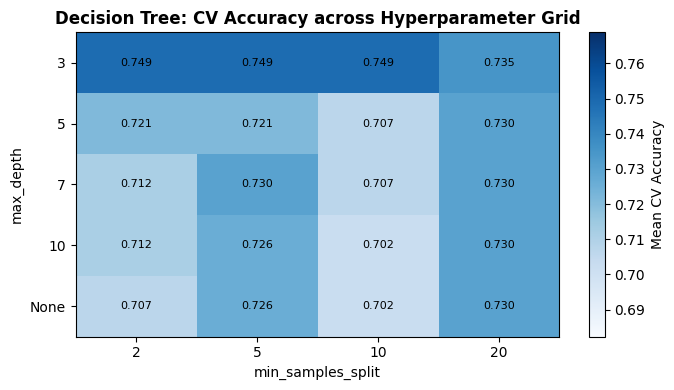

In [65]:
cv_df = pd.DataFrame(dt.cv_results_)

# Replace None with the string "None" so it can be used as an axis label
cv_df['param_max_depth'] = cv_df['param_max_depth'].fillna('None')

pivot = cv_df.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_split',
    values='mean_test_score'
)
# Keep depth in a sensible order: 3, 5, 7, 10, None
depth_order = [3, 5, 7, 10, 'None']
pivot = pivot.reindex([d for d in depth_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(7, 4))
sns_plot = plt.imshow(pivot.values, aspect='auto', cmap='Blues',
                      vmin=pivot.values.min() - 0.02,
                      vmax=pivot.values.max() + 0.02)
plt.colorbar(sns_plot, ax=ax, label='Mean CV Accuracy')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('min_samples_split')
ax.set_ylabel('max_depth')
ax.set_title('Decision Tree: CV Accuracy across Hyperparameter Grid',
             fontweight='bold')

# Annotate each cell with its score
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('./Data/Results/HyperparamImpact/hyperparam_dt.png', dpi=150)
plt.show()

Random Forest

In [66]:
print("Training Random Forest...")

rf_params = {
    'n_estimators': [10, 25, 50, 100, 200],
    'max_depth':    [3, 5, 10, None]
}

rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test, X_train.shape[1]))

Training Random Forest...

  Random Forest
  Accuracy : 0.8909
  Precision: 0.9500  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8636  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=30  FP=1
  FN=5  TP=19

  Best params: {'max_depth': 3, 'n_estimators': 50}


RF Hyperparameter Impact

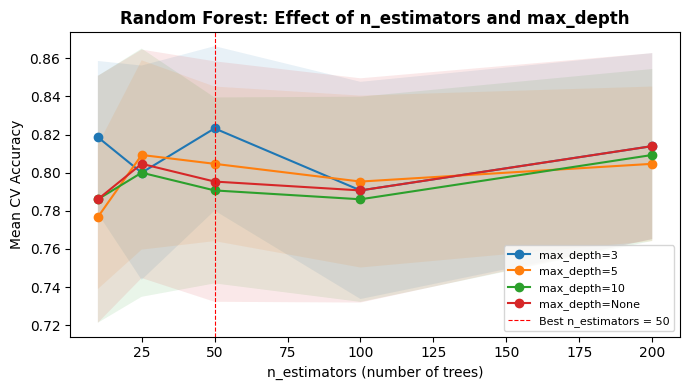

In [67]:
cv_df = pd.DataFrame(rf.cv_results_)
cv_df['param_max_depth'] = cv_df['param_max_depth'].fillna('None')

fig, ax = plt.subplots(figsize=(7, 4))
for depth in [3, 5, 10, 'None']:
    subset = cv_df[cv_df['param_max_depth'] == depth].sort_values('param_n_estimators')
    if subset.empty:
        continue
    ax.plot(subset['param_n_estimators'], subset['mean_test_score'],
            marker='o', label=f'max_depth={depth}')
    ax.fill_between(subset['param_n_estimators'],
                    subset['mean_test_score'] - subset['std_test_score'],
                    subset['mean_test_score'] + subset['std_test_score'],
                    alpha=0.1)

ax.axvline(rf.best_params_['n_estimators'], color='red', linestyle='--',
           linewidth=0.8, label=f"Best n_estimators = {rf.best_params_['n_estimators']}")
ax.set_xlabel('n_estimators (number of trees)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Random Forest: Effect of n_estimators and max_depth', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('./Data/Results/HyperparamImpact/hyperparam_rf.png', dpi=150)
plt.show()

XGBoost

In [68]:
print("Training XGBoost...")

xgb_params = {
    'n_estimators':  [10, 25, 50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth':     [3, 5, 7]
}

xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", xgb, X_test, y_test, X_train.shape[1]))

Training XGBoost...

  XGBoost
  Accuracy : 0.8364
  Precision: 0.8261  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8085  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=27  FP=4
  FN=5  TP=19

  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


XGBoost Hyperparameter Impact

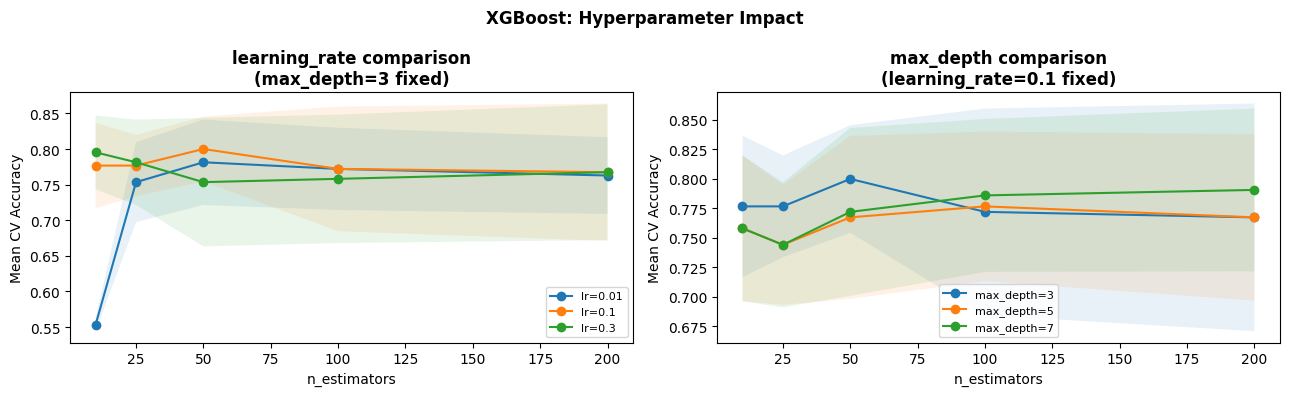

In [69]:
cv_df = pd.DataFrame(xgb.cv_results_)
best_lr   = xgb.best_params_['learning_rate']
best_md   = xgb.best_params_['max_depth']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: n_estimators vs accuracy, one line per learning_rate (max_depth fixed at best)
ax = axes[0]
for lr_val in [0.01, 0.1, 0.3]:
    subset = cv_df[
        (cv_df['param_learning_rate'] == lr_val) &
        (cv_df['param_max_depth'] == best_md)
    ].sort_values('param_n_estimators')
    ax.plot(subset['param_n_estimators'], subset['mean_test_score'],
            marker='o', label=f'lr={lr_val}')
    ax.fill_between(subset['param_n_estimators'],
                    subset['mean_test_score'] - subset['std_test_score'],
                    subset['mean_test_score'] + subset['std_test_score'],
                    alpha=0.1)
ax.set_xlabel('n_estimators')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title(f'learning_rate comparison\n(max_depth={best_md} fixed)',
             fontweight='bold')
ax.legend(fontsize=8)

# Right: n_estimators vs accuracy, one line per max_depth (learning_rate fixed at best)
ax = axes[1]
for md in [3, 5, 7]:
    subset = cv_df[
        (cv_df['param_max_depth'] == md) &
        (cv_df['param_learning_rate'] == best_lr)
    ].sort_values('param_n_estimators')
    ax.plot(subset['param_n_estimators'], subset['mean_test_score'],
            marker='o', label=f'max_depth={md}')
    ax.fill_between(subset['param_n_estimators'],
                    subset['mean_test_score'] - subset['std_test_score'],
                    subset['mean_test_score'] + subset['std_test_score'],
                    alpha=0.1)
ax.set_xlabel('n_estimators')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title(f'max_depth comparison\n(learning_rate={best_lr} fixed)',
             fontweight='bold')
ax.legend(fontsize=8)

fig.suptitle('XGBoost: Hyperparameter Impact', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./Data/Results/HyperparamImpact/hyperparam_xgb.png', dpi=150)
plt.show()

K-NN

In [70]:
print("Training KNN...")

knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric':      ['euclidean', 'manhattan']
}

knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn.fit(X_train, y_train)
results.append(evaluate("KNN", knn, X_test, y_test, X_train.shape[1]))

Training KNN...

  KNN
  Accuracy : 0.8182
  Precision: 0.8182  (of predicted positives, how many were right)
  Recall   : 0.7500  (of actual positives, how many did we catch)
  F1 Score : 0.7826  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=27  FP=4
  FN=6  TP=18

  Best params: {'metric': 'manhattan', 'n_neighbors': 11}


K-NN Hyperparameter Impact

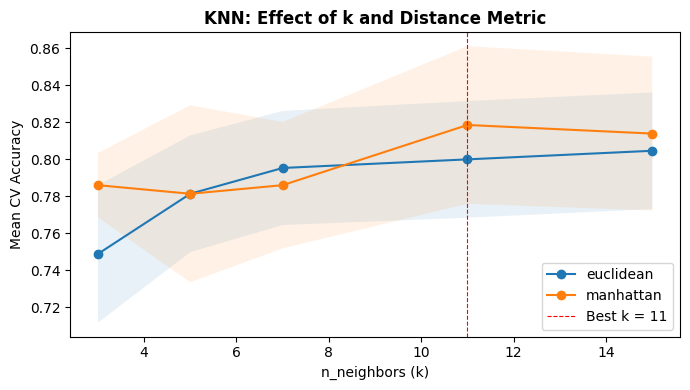

In [71]:
cv_df = pd.DataFrame(knn.cv_results_)

fig, ax = plt.subplots(figsize=(7, 4))
for metric in ['euclidean', 'manhattan']:
    subset = cv_df[cv_df['param_metric'] == metric].sort_values('param_n_neighbors')
    ax.plot(subset['param_n_neighbors'], subset['mean_test_score'],
            marker='o', label=metric)
    ax.fill_between(subset['param_n_neighbors'],
                    subset['mean_test_score'] - subset['std_test_score'],
                    subset['mean_test_score'] + subset['std_test_score'],
                    alpha=0.1)

ax.axvline(knn.best_params_['n_neighbors'], color='red', linestyle='--',
           linewidth=0.8, label=f"Best k = {knn.best_params_['n_neighbors']}")
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('KNN: Effect of k and Distance Metric', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./Data/Results/HyperparamImpact/hyperparam_knn.png', dpi=150)
plt.show()

In [72]:
models = {
    "Logistic Regression": lr,
    "SVM":                 svm,
    "Decision Tree":       dt,
    "Random Forest":       rf,
    "XGBoost":             xgb,
    "KNN":                 knn,
}


RFECV


Running LR + RFECV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  Best params   : {'classifier__C': 1, 'classifier__solver': 'lbfgs'}
  Features kept : 18 / 21
  Selected : ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type_Govt_job', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked']
  Dropped  : ['work_type_Private', 'work_type_Self-employed', 'smoking_status_smokes']


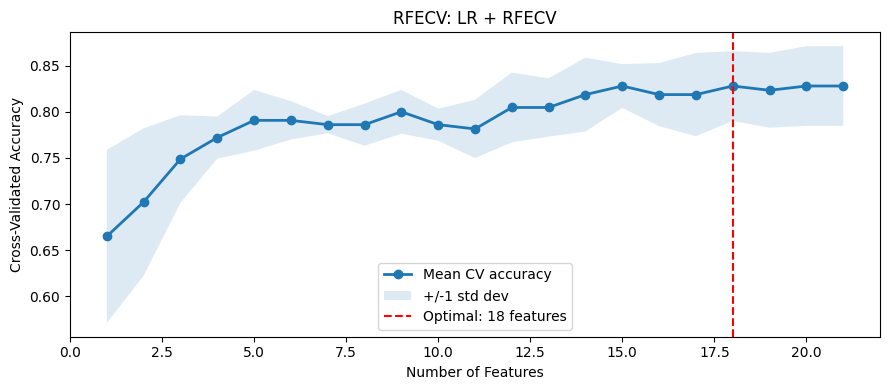


  LR + RFECV
  Accuracy : 0.8545
  Precision: 0.8636  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8261  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=28  FP=3
  FN=5  TP=19

Running SVM + RFECV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best params   : {'classifier__C': 0.1, 'classifier__kernel': 'linear'}
  Features kept : 17 / 21
  Selected : ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type_Govt_job', 'work_type_Private', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_smokes']
  Dropped  : ['EKG results', 'ST depression', 'work_type_Self-employed', 'smoking_status_never smoked']


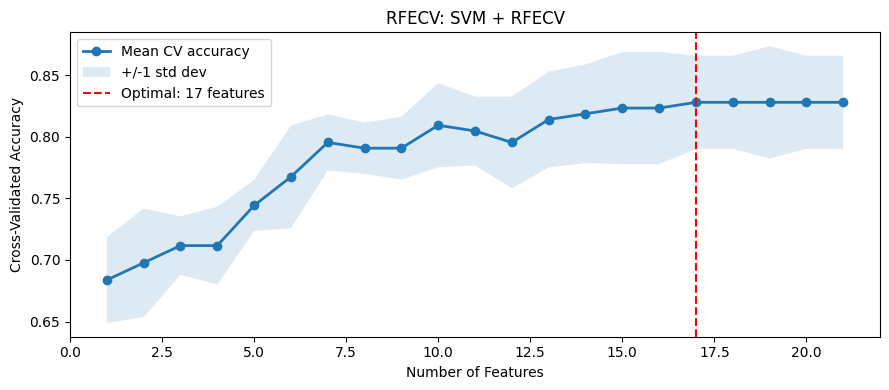


  SVM + RFECV
  Accuracy : 0.8182
  Precision: 0.7917  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.7917  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=26  FP=5
  FN=5  TP=19

Running DT + RFECV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best params   : {'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
  Features kept : 5 / 21
  Selected : ['Age', 'BP', 'Max HR', 'Number of vessels fluro', 'Thallium']
  Dropped  : ['Gender', 'Chest pain type', 'Cholesterol', 'FBS over 120', 'EKG results', 'Exercise angina', 'ST depression', 'Slope of ST', 'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


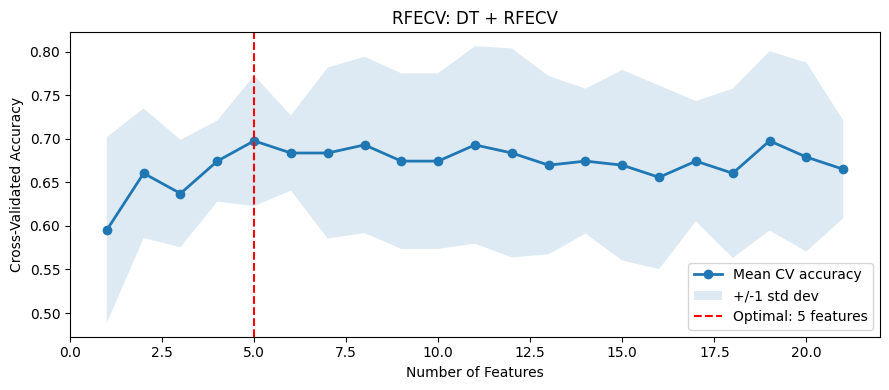


  DT + RFECV
  Accuracy : 0.6909
  Precision: 0.6296  (of predicted positives, how many were right)
  Recall   : 0.7083  (of actual positives, how many did we catch)
  F1 Score : 0.6667  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=21  FP=10
  FN=7  TP=17

Running DT + RFECV with RF scout...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best params   : {'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
  Features kept : 14 / 21
  Selected : ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type_Private', 'smoking_status_smokes']
  Dropped  : ['FBS over 120', 'work_type_Govt_job', 'work_type_Self-employed', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked']


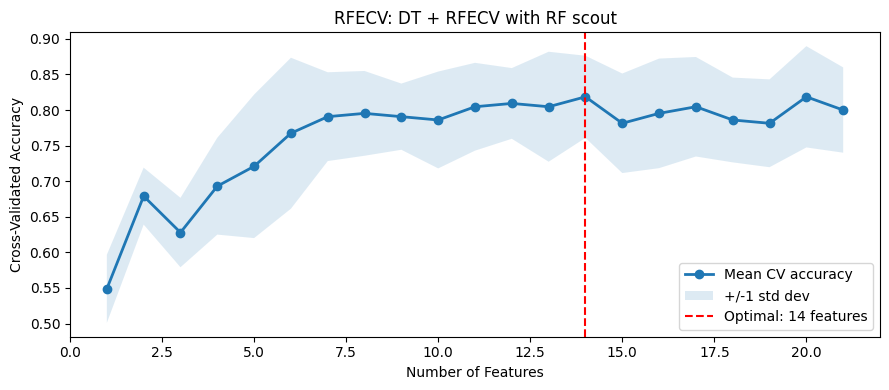


  DT + RFECV with RF scout
  Accuracy : 0.8545
  Precision: 0.8636  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8261  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=28  FP=3
  FN=5  TP=19

Running RF + RFECV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best params   : {'classifier__max_depth': 3, 'classifier__n_estimators': 200}
  Features kept : 14 / 21
  Selected : ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type_Private', 'smoking_status_smokes']
  Dropped  : ['FBS over 120', 'work_type_Govt_job', 'work_type_Self-employed', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked']


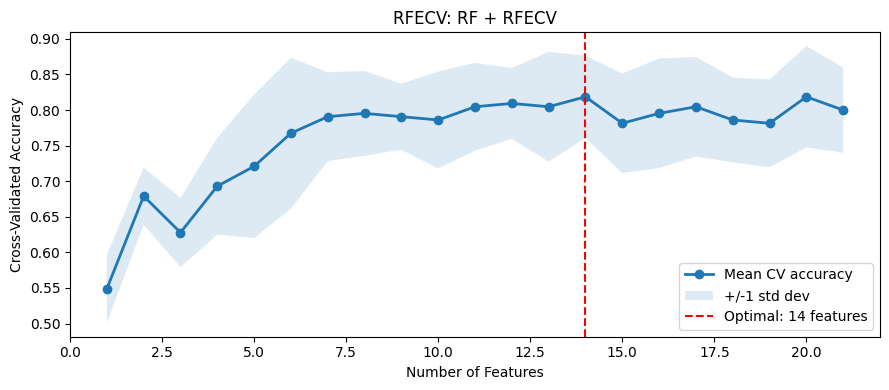


  RF + RFECV
  Accuracy : 0.8909
  Precision: 0.9500  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8636  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=30  FP=1
  FN=5  TP=19

Running XGB + RFECV...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
  Best params   : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 25}
  Features kept : 3 / 21
  Selected : ['Chest pain type', 'Number of vessels fluro', 'Thallium']
  Dropped  : ['Age', 'Gender', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


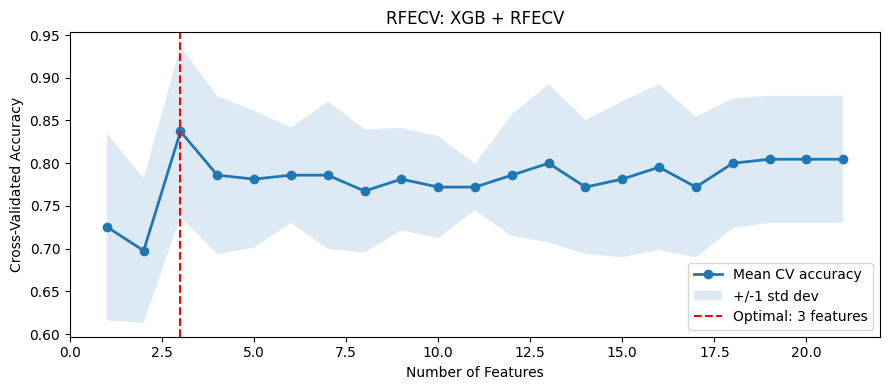


  XGB + RFECV
  Accuracy : 0.8545
  Precision: 0.8636  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8261  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=28  FP=3
  FN=5  TP=19

Running KNN + RFECV with RF scout...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  Best params   : {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11}
  Features kept : 14 / 21
  Selected : ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type_Private', 'smoking_status_smokes']
  Dropped  : ['FBS over 120', 'work_type_Govt_job', 'work_type_Self-employed', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked']


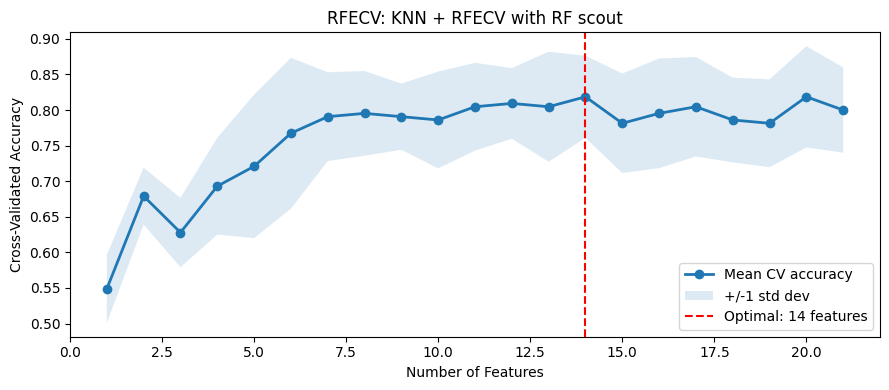


  KNN + RFECV with RF scout
  Accuracy : 0.8545
  Precision: 0.8636  (of predicted positives, how many were right)
  Recall   : 0.7917  (of actual positives, how many did we catch)
  F1 Score : 0.8261  (harmonic mean of precision & recall)

  Confusion Matrix:
  TN=28  FP=3
  FN=5  TP=19


In [73]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Each entry is: (display name, pipeline, param_grid)
# KNN is excluded -- it has no feature_importances_ or coef_, so RFECV
# cannot rank features with it.
# SVM uses kernel='linear' inside RFECV because only the linear kernel
# exposes coef_ for feature ranking. The final classifier step is free
# to use rbf after selection -- GridSearchCV will find whichever wins.
pipeline_configs = [
    (
        "LR + RFECV",
        Pipeline([
            ("selector",   RFECV(estimator=LogisticRegression(max_iter=1000, random_state=42),
                                 step=1, cv=cv_strategy, scoring='accuracy',
                                 min_features_to_select=1, n_jobs=-1)),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        {
            "classifier__C":      [0.01, 0.1, 1, 10, 100],
            "classifier__solver": ['lbfgs', 'liblinear']
        }
    ),
    (
        "SVM + RFECV",
        Pipeline([
            ("selector",   RFECV(estimator=SVC(kernel='linear', probability=True, random_state=42),
                                 step=1, cv=cv_strategy, scoring='accuracy',
                                 min_features_to_select=1, n_jobs=-1)),
            ("classifier", SVC(probability=True, random_state=42))
        ]),
        {
            "classifier__C":      [0.1, 1, 10, 100],
            "classifier__kernel": ['linear', 'rbf']
        }
    ),
    (
        "DT + RFECV",
        Pipeline([
            ("selector",   RFECV(estimator=DecisionTreeClassifier(random_state=42),
                                 step=1, cv=cv_strategy, scoring='accuracy',
                                 min_features_to_select=1, n_jobs=-1)),
            ("classifier", DecisionTreeClassifier(random_state=42))
        ]),
        {
            "classifier__max_depth":         [3, 5, 7, 10, None],
            "classifier__min_samples_split": [2, 5, 10, 20]
        }
    ),
    (
        "DT + RFECV with RF scout",
        Pipeline([
            ("selector",   RFECV(
                estimator=RandomForestClassifier(random_state=42),
                                # RF as the scout -- stable importances from
                                # averaging across many trees, much more reliable
                                # than a single DT for ranking decisions
                step=1, cv=cv_strategy, scoring='accuracy',
                min_features_to_select=1, n_jobs=-1
            )),
            ("classifier", DecisionTreeClassifier(random_state=42))
                                # DT still makes the final predictions -- we've
                                # just used a more trustworthy signal to decide
                                # which features to hand it
        ]),
        {
            "classifier__max_depth":         [3, 5, 7, 10, None],
            "classifier__min_samples_split": [2, 5, 10, 20]
        }
    ),
    (
        "RF + RFECV",
        Pipeline([
            ("selector",   RFECV(estimator=RandomForestClassifier(random_state=42),
                                 step=1, cv=cv_strategy, scoring='accuracy',
                                 min_features_to_select=1, n_jobs=-1)),
            ("classifier", RandomForestClassifier(random_state=42))
        ]),
        {
            "classifier__n_estimators": [10, 25, 50, 100, 200],
            "classifier__max_depth":    [3, 5, 10, None]
        }
    ),
    (
        "XGB + RFECV",
        Pipeline([
            ("selector",   RFECV(estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
                                 step=1, cv=cv_strategy, scoring='accuracy',
                                 min_features_to_select=1, n_jobs=-1)),
            ("classifier", XGBClassifier(random_state=42, eval_metric='logloss'))
        ]),
        {
            "classifier__n_estimators":  [10, 25, 50, 100, 200],
            "classifier__learning_rate": [0.01, 0.1, 0.3],
            "classifier__max_depth":     [3, 5, 7]
        }
    ),
    (
        "KNN + RFECV with RF scout",
        Pipeline([
            ("selector",   RFECV(
                estimator=RandomForestClassifier(random_state=42),
                step=1, cv=cv_strategy, scoring='accuracy',
                min_features_to_select=1, n_jobs=-1
            )),
            ("classifier", KNeighborsClassifier())
        ]),
        {
            "classifier__n_neighbors": [3, 5, 7, 11, 15],
            "classifier__metric":      ['euclidean', 'manhattan']
        }
    )
]

for name, pipeline, param_grid in pipeline_configs:
    print(f"\nRunning {name}...")

    gs = GridSearchCV(pipeline, param_grid, cv=cv_strategy,
                      scoring='accuracy', n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)

    best_pipe = gs.best_estimator_
    best_sel  = best_pipe.named_steps["selector"]
    selected  = X_train.columns[best_sel.support_].tolist()
    dropped   = X_train.columns[~best_sel.support_].tolist()

    print(f"  Best params   : {gs.best_params_}")
    print(f"  Features kept : {best_sel.n_features_} / {X_train.shape[1]}")
    print(f"  Selected : {selected}")
    print(f"  Dropped  : {dropped}")

    # RFECV performance curve -- saved with a per-model filename so each
    # pipeline's plot is preserved rather than overwriting the same file
    mean_scores    = best_sel.cv_results_["mean_test_score"]
    std_scores     = best_sel.cv_results_["std_test_score"]
    feature_counts = range(1, len(mean_scores) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(feature_counts, mean_scores, marker='o', linewidth=2, label='Mean CV accuracy')
    plt.fill_between(feature_counts, mean_scores - std_scores, mean_scores + std_scores,
                     alpha=0.15, label='+/-1 std dev')
    plt.axvline(x=best_sel.n_features_, color='red', linestyle='--',
                label=f'Optimal: {best_sel.n_features_} features')
    plt.xlabel('Number of Features')
    plt.ylabel('Cross-Validated Accuracy')
    plt.title(f'RFECV: {name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"./Data/Results/RFECV/rfecv_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

    results.append(evaluate(name, best_pipe, X_test, y_test, best_sel.n_features_))
    models[name] = best_pipe


Summary

In [78]:
print("\n\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)

summary = pd.DataFrame(results)[["Model Name", "Accuracy", "Precision", "Recall", "F1"]]
summary = summary.sort_values("F1", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

summary.to_csv("./Data/Results/model_summary.csv", index=False)
print("\nSummary saved to ./Data/Results/model_summary.csv")
print("Confusion matrix plots saved to ./Data/Results/")



  MODEL COMPARISON SUMMARY
               Model Name  Accuracy  Precision   Recall       F1
            Random Forest  0.890909   0.950000 0.791667 0.863636
               RF + RFECV  0.890909   0.950000 0.791667 0.863636
            Decision Tree  0.854545   0.863636 0.791667 0.826087
               LR + RFECV  0.854545   0.863636 0.791667 0.826087
 DT + RFECV with RF scout  0.854545   0.863636 0.791667 0.826087
KNN + RFECV with RF scout  0.854545   0.863636 0.791667 0.826087
              XGB + RFECV  0.854545   0.863636 0.791667 0.826087
      Logistic Regression  0.836364   0.826087 0.791667 0.808511
                  XGBoost  0.836364   0.826087 0.791667 0.808511
                      SVM  0.818182   0.791667 0.791667 0.791667
              SVM + RFECV  0.818182   0.791667 0.791667 0.791667
                      KNN  0.818182   0.818182 0.750000 0.782609
               DT + RFECV  0.690909   0.629630 0.708333 0.666667

Summary saved to ./Data/Results/model_summary.csv
Confusion 

Save Model

In [79]:
max_acc = 0
best_model_name = ""
best_model_result_index = -1
for i, model in enumerate(results):
    if model["Accuracy"] > max_acc:
        max_acc = model["Accuracy"]
        best_model_name = model["Model Name"]
        best_model_result_index = i
    elif model["Accuracy"] == max_acc and model["Feature_number"] < results[best_model_result_index]["Feature_number"]:
        print(f"  Tie in accuracy between {best_model_name} and {model['Model Name']}. Choosing the one with the least amount of data required.")
        max_acc = model["Accuracy"]
        best_model_name = model["Model Name"]
        best_model_result_index = i
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name} with accuracy: {max_acc:.4f}")
joblib.dump(best_model, f'./Data/Models/{best_model_name}.pkl')

  Tie in accuracy between Random Forest and RF + RFECV. Choosing the one with the least amount of data required.

Best model: RF + RFECV with accuracy: 0.8909


['./Data/Models/RF + RFECV.pkl']

Feature Importance

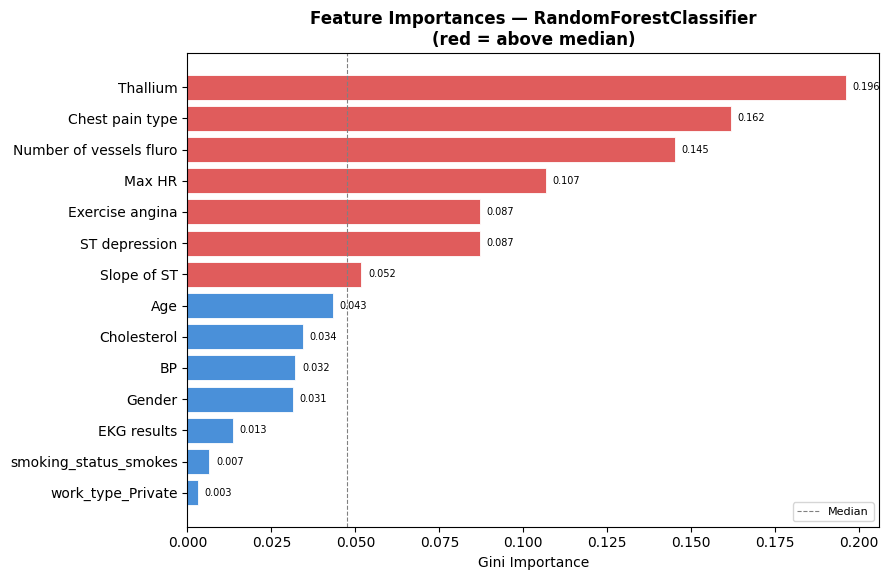

In [80]:
# ── Extract the actual model ──
if hasattr(best_model, 'named_steps'):
    model = best_model.named_steps["classifier"]
    feature_names = X_train.columns[best_model.named_steps["selector"].support_]
    X_eval = X_test[feature_names]
else:
    model = best_model.best_estimator_
    feature_names = X_test.columns
    X_eval = X_test

# ── Try native feature_importances_ first (tree-based), fall back to permutation ──
if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importance_type = "Gini Importance"
else:
    # Permutation importance works on any model
    perm_imp = permutation_importance(model, X_eval, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(perm_imp.importances_mean, index=feature_names)
    importance_type = "Permutation Importance"

importances = importances.sort_values(ascending=True)

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, len(importances) * 0.35 + 1))

colors = ["#E05C5C" if v >= importances.median() else "#4A90D9" for v in importances]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white', linewidth=0.6)

ax.set_xlabel(importance_type)
ax.set_title(f"Feature Importances — {model.__class__.__name__}\n(red = above median)", fontweight='bold')
ax.axvline(importances.median(), color='gray', linestyle='--', linewidth=0.8, label='Median')
ax.legend(fontsize=8)

for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + (importances.max() * 0.01), i, f"{val:.3f}", va='center', fontsize=7)

plt.tight_layout()
plt.savefig("./Data/Results/FeatureImportance/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

SHAP Summary

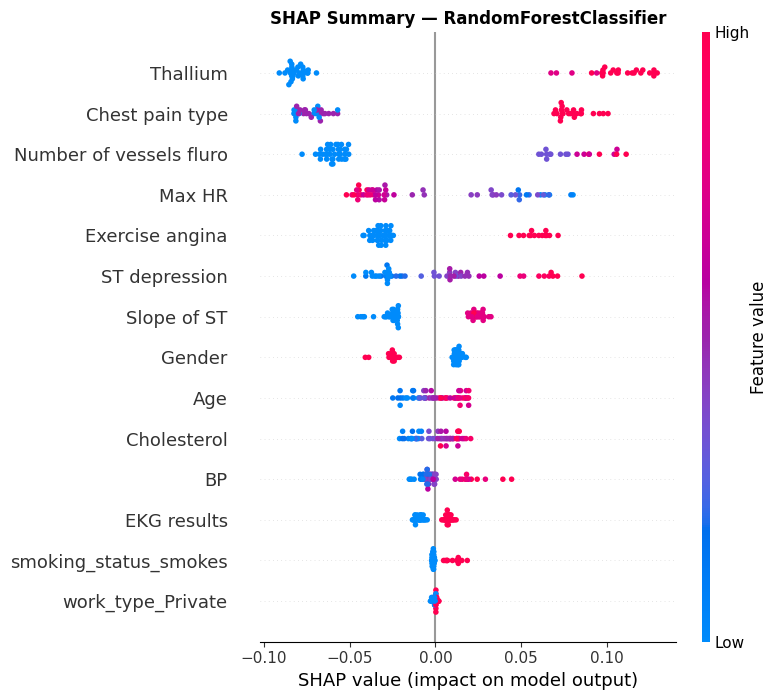

In [81]:
# ── SHAP summary plot ──
# Gini/permutation importance above only says HOW MUCH a feature matters on
# average. SHAP also shows the DIRECTION of each feature's effect (does a
# high value push toward "Disease" or away from it?) and how that effect
# varies per patient, not just as a single averaged number.

if hasattr(model, "feature_importances_"):
    # Tree-based models (Decision Tree, Random Forest, XGBoost) -- exact and fast
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_eval)

    # Different sklearn/xgboost versions return this differently for binary
    # classification -- normalise down to a single (n_samples, n_features)
    # array for the "Disease" (positive) class.
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
else:
    # Non-tree models (Logistic Regression, SVM, KNN) -- model-agnostic,
    # using predict_proba and a small sampled background for tractable runtime
    background = shap.sample(X_train[feature_names], 50, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_eval, nsamples=100)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

plt.figure()
shap.summary_plot(shap_values, X_eval, show=False)
plt.title(f"SHAP Summary — {model.__class__.__name__}", fontweight='bold')
plt.tight_layout()
plt.savefig("./Data/Results/FeatureImportance/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
